<div style="font-size: 24px; line-height: 1.6;">

# Gaming Whales and Dolphins: Outliers Run the Economy

## Outliers can be errors, edge cases, or the whole story

![Gaming Whales and Dolphins: Outliers Run the Economy](../images/whales.png)

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Takeaway

Functions introduced: `pd.read_parquet`, `describe`, `nunique`.

Functions reinforced: `value_counts`, `sort_values`, `groupby().agg`, `plot`.

**Concept learned: outliers can be errors, edge cases, or the whole story.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

### Imports

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (8, 5)

<div style="font-size: 24px; line-height: 1.6;">

## The story

Most players spend little. A tiny group of 'whales' spends a lot. The 'average player' may not exist. Removing outliers here would delete the business model.

</div>

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 1. Load the gaming dataset

Rows are players; columns include spend, sessions, and segment. The file is in **Parquet** — a columnar binary format common in modern data lakes. `pd.read_parquet()` reads it just like CSV, but loads much faster and preserves dtypes exactly. (Requires the `pyarrow` package.)

</div>

In [2]:
game = pd.read_parquet("../data/gaming_outliers.parquet")
game.head()

,player_id,monthly_spend,monthly_sessions,segment
0,1,0.62,4,minnow
1,2,2.63,10,minnow
2,3,1.62,4,minnow
3,4,11.08,6,minnow
4,5,6.95,16,minnow


In [3]:
game.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         10000 non-null  int64  
 1   monthly_spend     10000 non-null  float64
 2   monthly_sessions  10000 non-null  int64  
 3   segment           10000 non-null  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 372.0 KB


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 2. Distribution snapshot with `df.describe()`

Look at quartiles, mean, max, and spread. Compare the mean to the median — a big gap is your first whale alarm.

</div>

In [4]:
game["monthly_spend"].describe()

count    10000.000000
mean        12.738488
std        112.301636
min          0.010000
25%          1.110000
50%          3.160000
75%          9.340000
max      10012.370000
Name: monthly_spend, dtype: float64

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 3. Segment counts with `value_counts()`

Whales are rare by count.

</div>

In [5]:
game["segment"].value_counts()

segment
minnow     9000
dolphin     900
whale       100
Name: count, dtype: int64

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 4. Unique values with `df.nunique()`

`nunique()` helps you tell IDs apart from categories and continuous variables.

</div>

In [6]:
game.nunique()

player_id           10000
monthly_spend        2743
monthly_sessions       63
segment                 3
dtype: int64

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 5. Sort the heavy tail

Look directly at the top spenders.

</div>

In [7]:
game.sort_values("monthly_spend", ascending=False).head(20)

,player_id,monthly_spend,monthly_sessions,segment
9359,9360,10012.37,57,whale
5281,5282,3371.37,54,whale
500,501,2300.03,55,whale
157,158,1274.92,55,whale
2564,2565,660.43,49,whale
4815,4816,642.34,51,whale
2950,2951,549.50,51,whale
1962,1963,516.43,51,whale
81,82,508.88,48,whale
1603,1604,453.67,45,whale


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 6. Visualize the distribution

A histogram is the most direct way to *see* a heavy tail.

</div>

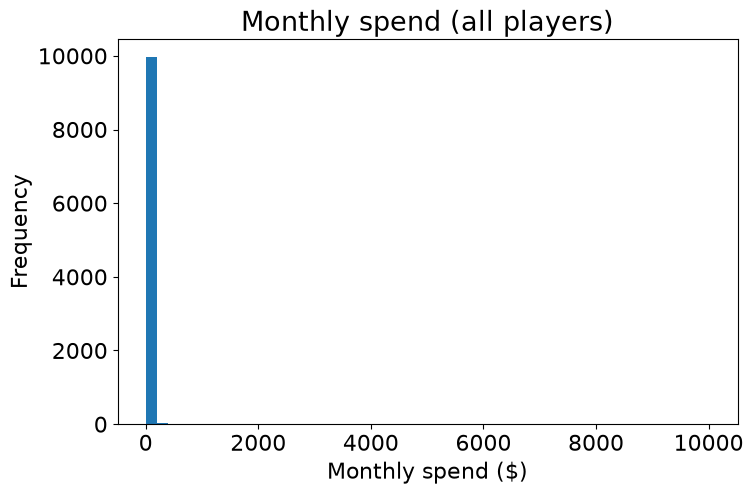

In [8]:
game["monthly_spend"].plot(kind="hist", bins=50, title="Monthly spend (all players)")
plt.xlabel("Monthly spend ($)")
plt.show()

<div style="font-size: 24px; line-height: 1.6;">

And on a log scale, so you can see what's hiding in the tail:

</div>

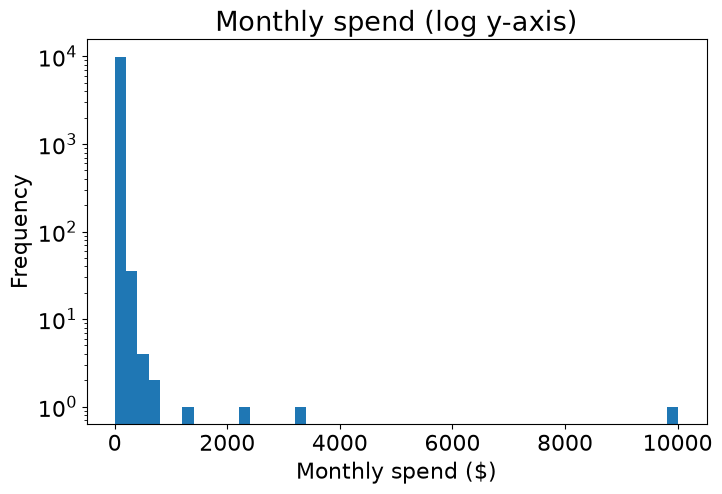

In [9]:
game["monthly_spend"].plot(kind="hist", bins=50, log=True,
                           title="Monthly spend (log y-axis)")
plt.xlabel("Monthly spend ($)")
plt.show()

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 7. Group revenue by segment

Revenue contribution matters more than player count.

</div>

In [10]:
segment_summary = game.groupby("segment").agg(
    players=("player_id", "count"),
    avg_spend=("monthly_spend", "mean"),
    total_spend=("monthly_spend", "sum"),
)
segment_summary

,players,avg_spend,total_spend
segment,,,
dolphin,900,50.936744,45843.07
minnow,9000,4.806324,43256.92
whale,100,382.848900,38284.89


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 8. What share of revenue comes from each segment?

Dividing each segment's total by the grand total turns raw sums into shares — the number that tells you who actually funds the game.

</div>

In [11]:
segment_summary["revenue_share"] = (
    segment_summary["total_spend"] / segment_summary["total_spend"].sum()
)
segment_summary[["players", "total_spend", "revenue_share"]].round(3)

,players,total_spend,revenue_share
segment,,,
dolphin,900,45843.07,0.360
minnow,9000,43256.92,0.340
whale,100,38284.89,0.301


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 9. Should we remove the whales?

Not automatically. Decide whether outliers are:

- **errors** (drop them),
- **rare valid users** (keep, but report separately), or
- **the business itself** (keep, and never quote a plain mean).

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Discussion

- A teammate reports 'the average player spends $X/month'. Why is this misleading?
- What number would be more honest to report instead?

*Try to answer first. The answer is written in **white** — highlight the block below (drag your cursor across the empty space) to reveal it.*

<p style="color: #ffffff;"><strong>Answer.</strong> The mean is dragged up by a handful of whales, so '&#36;X/month' describes almost no actual player — most spend far less. Report the <strong>median</strong> (about &#36;3 here, the 50% row of <code>describe()</code>) with the quartiles, or the revenue-share-by-segment table, so both the typical player and the heavy tail are visible.</p>

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Why this matters to a data scientist

Heavy tails are the rule in tech data, not the exception: revenue per customer, session length, tokens per request, file sizes, follower counts. Two practical consequences:

- **Report distributions, not means.** 'The average player spends $12.74' is technically true and practically false — the *median* player spends about $3 (the 50% row in `describe()` above). Quote the median, the quartiles, or the revenue-share table you built.
- **Never remove outliers on autopilot.** A preprocessing step that clips 'anomalies' would delete the whales here — and with them, most of the revenue. In an ML pipeline, automatic outlier removal can silently amputate the exact behavior the business runs on.

</div>